In [32]:
import sys
print(sys.executable)
# LÆG MÆRKE TIL DER ER 2 VERSIONER AF PYTHON 3.11.9. En version hvor Microsoft\WindowsApps er en del af PATH/addresse, 
# og en hvor det ikke er en del af PATH/addresse. Sørg for at vælge den der IKKE inderholder Microsoft/Windows
# (Gælder kun for min Bærbar Computer)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


$$r_{t,t+5}=\frac{close\_future - close\_now}{close\_now}$$

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Write the folder name only once
data_folder = "res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0" # HUSK AT VÆLGE DET RIGTIGE MAPPE NAVN

pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

print(df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  future_return_5d
0   CCEP     2024-06-28      0.608606          0.007685
1    DOV     2024-06-28      0.446842         -0.021945
2    BCE     2024-06-28      0.837209         -0.019771
3    HIG     2024-06-28      0.372380         -0.013825
4    COR     2024-06-28      0.409034         -0.007146


In [34]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------
# Load predictions
# ----------------------------
data_folder = "res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0"   # choose the right folder
pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

# ----------------------------
# Settings
# ----------------------------
n_groups = 10      # 10 = deciles
holding_days = 5   # R5 horizon

# ----------------------------
# Prepare variables
# ----------------------------
df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

df = df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].dropna().copy()

# If your file contains DAILY rolling predictions, but you want paper-style
# non-overlapping 5-day rebalances, uncomment these 2 lines:
# keep_dates = sorted(df["rebalance_date"].unique())[::holding_days]
# df = df[df["rebalance_date"].isin(keep_dates)].copy()

def assign_groups(probs: pd.Series, n_groups: int = 10) -> pd.Series:
    """
    Assign 1..n_groups within each rebalance date.
    rank(method='first') avoids qcut problems when probabilities tie.
    """
    if probs.notna().sum() < n_groups:
        return pd.Series(np.nan, index=probs.index)

    ranks = probs.rank(method="first")
    groups = pd.qcut(ranks, q=n_groups, labels=False) + 1
    return pd.Series(groups, index=probs.index)

# ----------------------------
# Sort into deciles within each rebalance date
# ----------------------------
df["decile"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(lambda x: assign_groups(x, n_groups=n_groups))
)

df = df.dropna(subset=["decile"]).copy()
df["decile"] = df["decile"].astype(int)

# ----------------------------
# Equal-weight portfolio return for each date x decile
# ----------------------------
period_ret = (
    df.groupby(["rebalance_date", "decile"])["future_return_5d"]
      .mean()
      .unstack("decile")
      .sort_index(axis=1)
)

# keep only dates where all deciles exist
period_ret = period_ret.dropna()

# ----------------------------
# Annualization helpers
# ----------------------------
ann_factor = 252 / holding_days

def annualized_return(x: pd.Series) -> float:
    return x.mean() * ann_factor

def annualized_sharpe(x: pd.Series) -> float:
    s = x.std(ddof=1)
    if pd.isna(s) or s == 0:
        return np.nan
    return (x.mean() / s) * np.sqrt(ann_factor)

# ----------------------------
# Build decile summary table
# ----------------------------
summary = pd.DataFrame({
    "Ret": period_ret.apply(annualized_return),
    "SR": period_ret.apply(annualized_sharpe),
})

# High-minus-Low
hl = period_ret[n_groups] - period_ret[1]
summary.loc["H-L", "Ret"] = annualized_return(hl)
summary.loc["H-L", "SR"]  = annualized_sharpe(hl)

# Optional significance stars for H-L mean return
tstat, pval = stats.ttest_1samp(hl.dropna(), popmean=0.0)
if pval < 0.001:
    stars = "***"
elif pval < 0.01:
    stars = "**"
elif pval < 0.05:
    stars = "*"
else:
    stars = ""

# Rename rows to match the paper style
summary = summary.rename(index={1: "Low", n_groups: "High"})

ordered_rows = ["Low"] + [i for i in range(2, n_groups)] + ["High", "H-L"]
summary = summary.loc[ordered_rows]

# Pretty printed version
table_out = summary.copy().reset_index()
table_out.columns = ["Decile", "Ret", "SR"]
table_out["Decile"] = table_out["Decile"].astype(str)
table_out.loc[table_out["Decile"] == "H-L", "Decile"] = f"H-L{stars}"

table_out["Ret"] = table_out["Ret"].map(lambda x: f"{x:.2f}")
table_out["SR"]  = table_out["SR"].map(lambda x: f"{x:.2f}")

print(table_out.to_string(index=False))

Decile  Ret   SR
   Low 0.04 0.32
     2 0.10 0.63
     3 0.27 1.58
     4 0.14 0.82
     5 0.26 1.43
     6 0.12 0.83
     7 0.20 1.34
     8 0.04 0.25
     9 0.19 1.16
  High 0.16 1.11
   H-L 0.12 1.01


In [35]:
print(period_ret.mean())
print(hl.mean())

decile
1     0.000772
2     0.001895
3     0.005315
4     0.002852
5     0.005187
6     0.002400
7     0.003963
8     0.000758
9     0.003802
10    0.003101
dtype: float64
0.002328876295114008


In [36]:
counts = df.groupby("rebalance_date")["ticker"].nunique()
print(counts.describe())
print(counts.head(20))

count     25.000000
mean     194.320000
std        0.476095
min      194.000000
25%      194.000000
50%      194.000000
75%      195.000000
max      195.000000
Name: ticker, dtype: float64
rebalance_date
2024-06-28    194
2024-07-08    194
2024-07-15    194
2024-07-22    194
2024-07-29    194
2024-08-05    194
2024-08-12    194
2024-08-19    194
2024-08-26    194
2024-09-03    194
2024-09-10    194
2024-09-17    194
2024-09-24    194
2024-10-01    194
2024-10-08    194
2024-10-15    194
2024-10-22    194
2024-10-29    195
2024-11-05    195
2024-11-12    195
Name: ticker, dtype: int64


In [37]:
decile_counts = df.groupby(["rebalance_date", "decile"])["ticker"].nunique().unstack()
print(decile_counts.head())
print(decile_counts.describe())

decile          1   2   3   4   5   6   7   8   9   10
rebalance_date                                        
2024-06-28      20  19  19  20  19  19  20  19  19  20
2024-07-08      20  19  19  20  19  19  20  19  19  20
2024-07-15      20  19  19  20  19  19  20  19  19  20
2024-07-22      20  19  19  20  19  19  20  19  19  20
2024-07-29      20  19  19  20  19  19  20  19  19  20
decile    1     2          3          4          5     6          7   \
count   25.0  25.0  25.000000  25.000000  25.000000  25.0  25.000000   
mean    20.0  19.0  19.320000  19.680000  19.320000  19.0  19.680000   
std      0.0   0.0   0.476095   0.476095   0.476095   0.0   0.476095   
min     20.0  19.0  19.000000  19.000000  19.000000  19.0  19.000000   
25%     20.0  19.0  19.000000  19.000000  19.000000  19.0  19.000000   
50%     20.0  19.0  19.000000  20.000000  19.000000  19.0  20.000000   
75%     20.0  19.0  20.000000  20.000000  20.000000  19.0  20.000000   
max     20.0  19.0  20.000000  20.00000

In [38]:
n_groups = 10   # use 10 in final analysis

In [39]:
def assign_groups(prob_series):
    if len(prob_series) < n_groups:
        return pd.Series([np.nan] * len(prob_series), index=prob_series.index)

    ranked = prob_series.rank(method="first")

    return pd.qcut(
        ranked,
        q=n_groups,
        labels=False
    ) + 1

df["group"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(assign_groups)
)

df = df.dropna(subset=["group"]).copy()
df["group"] = df["group"].astype(int)

print(df[["ticker", "rebalance_date", "pred_prob_up", "group", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  group  future_return_5d
0   CCEP     2024-06-28      0.608606      4          0.007685
1    DOV     2024-06-28      0.446842      1         -0.021945
2    BCE     2024-06-28      0.837209      9         -0.019771
3    HIG     2024-06-28      0.372380      1         -0.013825
4    COR     2024-06-28      0.409034      1         -0.007146


In [40]:
portfolio_returns = (
    df.groupby(["rebalance_date", "group"])["future_return_5d"]
      .mean()
      .reset_index()
)

print(portfolio_returns.head())

  rebalance_date  group  future_return_5d
0     2024-06-28      1         -0.009332
1     2024-06-28      2          0.008105
2     2024-06-28      3          0.004530
3     2024-06-28      4          0.007530
4     2024-06-28      5          0.000859


In [41]:
portfolio_wide = portfolio_returns.pivot(
    index="rebalance_date",
    columns="group",
    values="future_return_5d"
)

portfolio_wide.columns = [f"G{int(c)}" for c in portfolio_wide.columns]

low_col = "G1"
high_col = f"G{n_groups}"

portfolio_wide["H-L"] = portfolio_wide[high_col] - portfolio_wide[low_col]

print(portfolio_wide.head())

                      G1        G2        G3        G4        G5        G6  \
rebalance_date                                                               
2024-06-28     -0.009332  0.008105  0.004530  0.007530  0.000859 -0.010851   
2024-07-08     -0.012218  0.032857  0.029086  0.036393  0.042302  0.017856   
2024-07-15     -0.000989 -0.002251 -0.017621 -0.003056  0.006022 -0.010265   
2024-07-22     -0.001950  0.007728 -0.013385 -0.000146 -0.004857  0.007980   
2024-07-29     -0.022083 -0.022224 -0.038316 -0.059357 -0.043599 -0.051709   

                      G7        G8        G9       G10       H-L  
rebalance_date                                                    
2024-06-28     -0.006114 -0.007949  0.005590  0.011526  0.020857  
2024-07-08      0.017282  0.011578  0.031504  0.017356  0.029574  
2024-07-15      0.009504  0.008512 -0.000888 -0.002758 -0.001769  
2024-07-22     -0.024038 -0.005469  0.018852 -0.012948 -0.010997  
2024-07-29     -0.041896 -0.049001 -0.050734 -0.042

In [42]:
periods_per_year = 252 / 5

def annualized_return(r):
    return r.mean() * periods_per_year

def annualized_sharpe(r):
    std = r.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return (r.mean() / std) * np.sqrt(periods_per_year)

def p_value_mean_zero(r):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    t_stat, p_val = stats.ttest_1samp(r, popmean=0.0, nan_policy="omit")
    return p_val

def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary_rows = []

for g in range(1, n_groups + 1):
    col = f"G{g}"
    r = portfolio_wide[col].dropna()

    if g == 1:
        label = "Low"
    elif g == n_groups:
        label = "High"
    else:
        label = str(g)

    p = p_value_mean_zero(r)

    summary_rows.append({
        "Group": label,
        "Ret": annualized_return(r),
        "SR": annualized_sharpe(r),
        "p_value": p,
        "stars": stars_from_p(p)
    })

# Add H-L
r_hl = portfolio_wide["H-L"].dropna()
p_hl = p_value_mean_zero(r_hl)

summary_rows.append({
    "Group": "H-L",
    "Ret": annualized_return(r_hl),
    "SR": annualized_sharpe(r_hl),
    "p_value": p_hl,
    "stars": stars_from_p(p_hl)
})

summary_table = pd.DataFrame(summary_rows)

summary_table["Ret"] = summary_table["Ret"].round(2)
summary_table["SR_display"] = summary_table["SR"].map(lambda x: f"{x:.2f}") + summary_table["stars"]

print(summary_table[["Group", "Ret", "SR_display", "p_value"]].to_string(index=False))

Group  Ret SR_display  p_value
  Low 0.04       0.32 0.821904
    2 0.10       0.63 0.659349
    3 0.27       1.58 0.276551
    4 0.14       0.82 0.568405
    5 0.26       1.43 0.324133
    6 0.12       0.83 0.563276
    7 0.20       1.34 0.354704
    8 0.04       0.25 0.860734
    9 0.19       1.16 0.420884
 High 0.16       1.11 0.442433
  H-L 0.12       1.01 0.481786


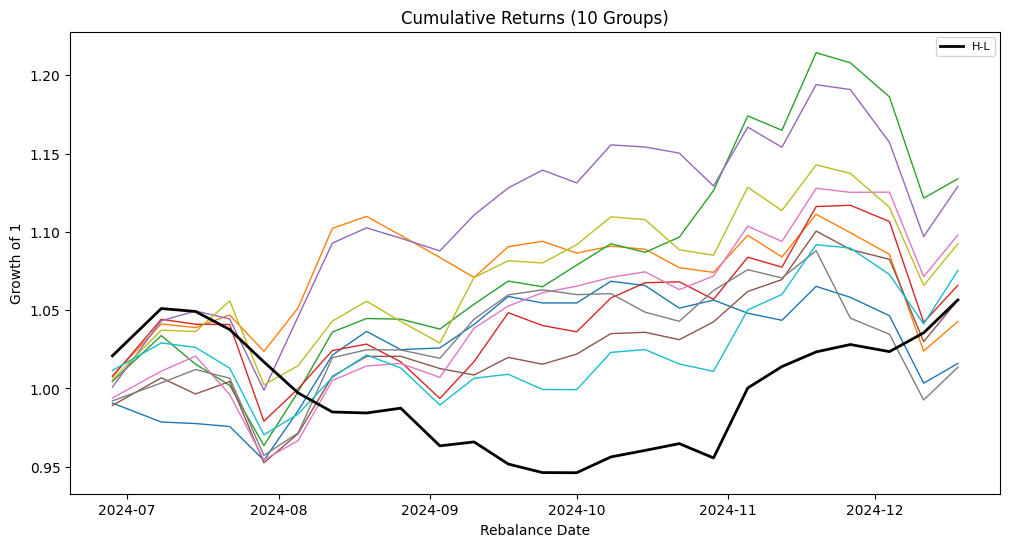

In [43]:
cum_df = (1 + portfolio_wide.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(cum_df.index, cum_df[f"G{g}"], linewidth=1)

plt.plot(cum_df.index, cum_df["H-L"], linewidth=2, color="black", label="H-L")

plt.title(f"Cumulative Returns ({n_groups} Groups)")
plt.ylabel("Growth of 1")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()

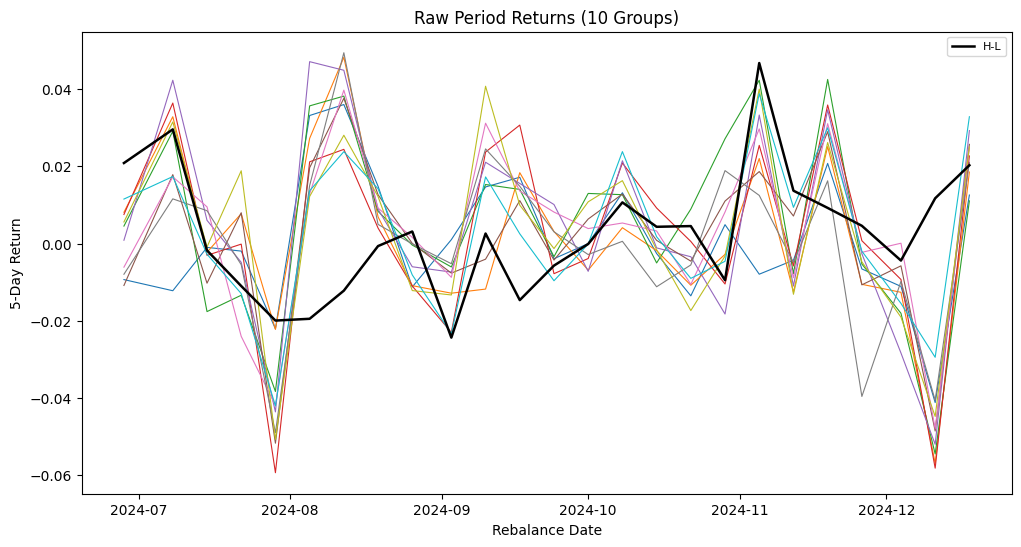

In [44]:
plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(portfolio_wide.index, portfolio_wide[f"G{g}"], linewidth=0.8)

plt.plot(portfolio_wide.index, portfolio_wide["H-L"], linewidth=1.8, color="black", label="H-L")

plt.title(f"Raw Period Returns ({n_groups} Groups)")
plt.ylabel("5-Day Return")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()